# EDA

In [2]:
import pandas as pd
import matplotlib as plt
import numpy as np

### Ordem de EDA

#### ETL

- Importar dados
- Usar funções visualizações iniciais
- Transformar tipos/renomerar colunas/conveter valores
- Unificar df(s)/dropar colunas redundante
- Idêntificar, subistituir ou remover valores ausentes

#### Análise

- Aplicando medidas de posição
- Analisar os dados categoricos
- Analisar os dados númericos
- Filtro e agrupamentos de valores númericos para seguimentação de valores de interesse 

### Importando os dados

In [3]:
df_clientes = pd.read_csv(r"..\analise_exploratoria\datasets\churn_customers.csv")
df_servico = pd.read_csv(r"..\analise_exploratoria\datasets\churn_services.csv")
df_contratos =  pd.read_csv(r"..\analise_exploratoria\datasets\churn_contracts.csv")

### Usando funções de visualização inicial

In [4]:
df_clientes.head()

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [5]:
df_clientes.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents
7038,6840-RESVB,Male,0,Yes,Yes
7039,2234-XADUH,Female,0,Yes,Yes
7040,4801-JZAZL,Female,0,Yes,Yes
7041,8361-LTMKD,Male,1,Yes,No
7042,3186-AJIEK,Male,0,No,No


In [6]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


In [7]:
df_clientes.describe()

,SeniorCitizen
count,7043.000000
mean,0.162147
std,0.368612
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [8]:
df_clientes.dtypes

customerID       object
gender           object
SeniorCitizen     int64
Partner          object
Dependents       object
dtype: object

In [9]:
df_clientes.shape

(7043, 5)

### Tranformação de dados

In [10]:
df_contratos.dtypes

customerID           object
tenure                int64
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [11]:
df_contratos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   tenure            7043 non-null   int64  
 2   Contract          7043 non-null   object 
 3   PaperlessBilling  7043 non-null   object 
 4   PaymentMethod     7043 non-null   object 
 5   MonthlyCharges    7043 non-null   float64
 6   TotalCharges      7043 non-null   object 
 7   Churn             7043 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 440.3+ KB


In [12]:
df_contratos.head(2)

,customerID,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,One year,No,Mailed check,56.95,1889.5,No


In [13]:
#  Aplicando a np.nan espações vazios '' ou ' '
df_contratos["TotalCharges"]  = df_contratos["TotalCharges"].replace(['', ' '], np.nan)

#ou 

''' 
Assim ele já cdetecta o tipo e elimina espaçõs, porem é menos personalizado, mas é rápido

df_contratos["TotalCharges"] =  pd.to_numeric(df_contratos['TotalCharges'], errors='coerce')
'''

' \nAssim ele já cdetecta o tipo e elimina espaçõs, porem é menos personalizado, mas é rápido\n\ndf_contratos["TotalCharges"] =  pd.to_numeric(df_contratos[\'TotalCharges\'], errors=\'coerce\')\n'

In [14]:
#  Alterando tipo do da coluna TotalCharges de object para float64
df_contratos["TotalCharges"]  = df_contratos["TotalCharges"].astype("Float64")

### Renomeando colunas 

In [15]:
# Statísticas gerais

df_clientes.info()
print(df_clientes.dtypes)
df_clientes.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB
customerID       object
gender           object
SeniorCitizen     int64
Partner          object
Dependents       object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No


In [16]:
#Renomeando coluna de pessoas idesas
df_clientes.rename(columns={"SeniorCitizen" : "ElderlyPerson"}, inplace=True)

In [17]:
# Renomeando colunas de pessoas casadas
df_clientes.rename(columns={"Partner" : "Casado(a)"}, inplace=True)

In [18]:
# Interressante, posso renomear todas as colunas sem o rename
df_clientes.columns = ["IDCliente", "Genero", "PessoaIdosa", "Casado(a)", "Dependentes"]

### Unindo df(s)

In [19]:
df_servico.head(2)
df_clientes.head(2)
print(f"servições: {df_servico.shape}\nclientes: {df_clientes.shape}")

servições: (7043, 10)
clientes: (7043, 5)


In [20]:
# Renomeando chave primaria para a junção
df_servico.rename(columns={"customerID" : "IDCliente"}, inplace= True)

In [21]:
# Juntando df_servso e df_cliente
df_temp = df_clientes.merge(df_servico, on=["IDCliente"])
df_temp.head(5)

,IDCliente,Genero,PessoaIdosa,Casado(a),Dependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No


In [22]:
# visualizando df resultate do merge
print(df_temp.shape)
print(df_temp.info())

(7043, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   IDCliente         7043 non-null   object
 1   Genero            7043 non-null   object
 2   PessoaIdosa       7043 non-null   int64 
 3   Casado(a)         7043 non-null   object
 4   Dependentes       7043 non-null   object
 5   PhoneService      7043 non-null   object
 6   MultipleLines     7043 non-null   object
 7   InternetService   7043 non-null   object
 8   OnlineSecurity    7043 non-null   object
 9   OnlineBackup      7043 non-null   object
 10  DeviceProtection  7043 non-null   object
 11  TechSupport       7043 non-null   object
 12  StreamingTV       7043 non-null   object
 13  StreamingMovies   7043 non-null   object
dtypes: int64(1), object(13)
memory usage: 770.5+ KB
None


In [23]:
df_contratos.head(2)

,customerID,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,One year,No,Mailed check,56.95,1889.5,No


In [24]:
# Realizando a junçãod do df_temp e df_contratos sem a alterar nome de colunas
df_churn_tmep = df_temp.merge(df_contratos, left_on=["IDCliente"], right_on=["customerID"])
df_churn_tmep.head(2)

,IDCliente,Genero,PessoaIdosa,Casado(a),Dependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,customerID,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,7590-VHVEG,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,5575-GNVDE,34,One year,No,Mailed check,56.95,1889.5,No


In [25]:
# Analisando df resultante do merge
print(df_churn_tmep.shape)
print(df_churn_tmep.info())

(7043, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   IDCliente         7043 non-null   object 
 1   Genero            7043 non-null   object 
 2   PessoaIdosa       7043 non-null   int64  
 3   Casado(a)         7043 non-null   object 
 4   Dependentes       7043 non-null   object 
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  customerID        7043 non-null   object 
 15  tenure            7043 non-null   int64  
 16  Contract          7043 non-null

In [26]:
# Crinado df definitivo em uma única linha
df_churn =  df_clientes.merge(df_servico, on=["IDCliente"]).merge(df_contratos,left_on=["IDCliente"], right_on=["customerID"])
df_churn.head(2)

,IDCliente,Genero,PessoaIdosa,Casado(a),Dependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,customerID,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,7590-VHVEG,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,5575-GNVDE,34,One year,No,Mailed check,56.95,1889.5,No


In [27]:
# Analisando df resultante
print(df_churn.shape)
print(df_churn.info())

(7043, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   IDCliente         7043 non-null   object 
 1   Genero            7043 non-null   object 
 2   PessoaIdosa       7043 non-null   int64  
 3   Casado(a)         7043 non-null   object 
 4   Dependentes       7043 non-null   object 
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  customerID        7043 non-null   object 
 15  tenure            7043 non-null   int64  
 16  Contract          7043 non-null

In [28]:
# Removendo coluna redundante
df_churn.drop(columns=["customerID"], inplace=True, axis=1) # axis = 1 para coluna

### Detecção de valores ausentes

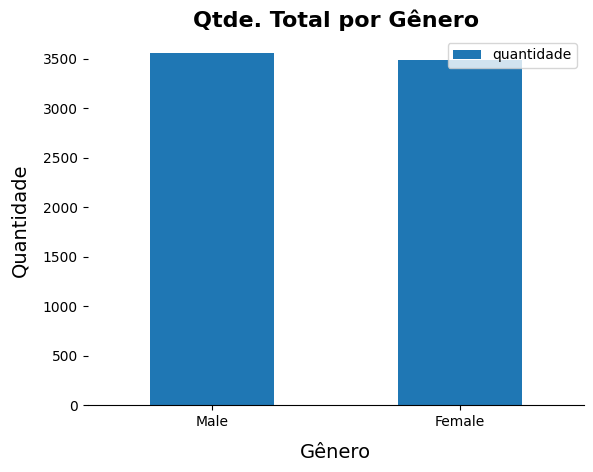

In [29]:
# Testando abilidade com matplotlib

distribuicao_genero = df_churn["Genero"].value_counts().reset_index() # Sempre usar o reset.index() para reconverter para df

distribuicao_genero.columns = ["genero", "quantidade"] # Alterando nome colunas

distribuicao_genero = distribuicao_genero.plot.bar(x="genero", y="quantidade", rot=0)
distribuicao_genero.set_title("Qtde. Total por Gênero", fontsize=16, loc='center', fontweight='bold')
distribuicao_genero.set_xlabel("Gênero", fontsize=14, labelpad=10)
distribuicao_genero.set_ylabel("Quantidade", fontsize=14, labelpad=10)
distribuicao_genero.spines[['right', 'left', 'top']].set_visible(False)


In [30]:
# isna retorna o df com True(s) e False(s), quando uso sum consigo visualizar a quantidade
df_churn.isna().sum()

IDCliente            0
Genero               0
PessoaIdosa          0
Casado(a)            0
Dependentes          0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
tenure               0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [31]:
# Observando quais valores são nulos das colunas 
df_churn[df_churn.isna().any(axis=1)]

,IDCliente,Genero,PessoaIdosa,Casado(a),Dependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,...,Yes,Yes,No,0,Two year,Yes,Bank transfer (automatic),52.55,<NA>,No
753,3115-CZMZD,Male,0,No,Yes,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,0,Two year,No,Mailed check,20.25,<NA>,No
936,5709-LVOEQ,Female,0,Yes,Yes,Yes,No,DSL,Yes,Yes,...,No,Yes,Yes,0,Two year,No,Mailed check,80.85,<NA>,No
1082,4367-NUYAO,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,0,Two year,No,Mailed check,25.75,<NA>,No
1340,1371-DWPAZ,Female,0,Yes,Yes,No,No phone service,DSL,Yes,Yes,...,Yes,Yes,No,0,Two year,No,Credit card (automatic),56.05,<NA>,No
3331,7644-OMVMY,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,0,Two year,No,Mailed check,19.85,<NA>,No
3826,3213-VVOLG,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,0,Two year,No,Mailed check,25.35,<NA>,No
4380,2520-SGTTA,Female,0,Yes,Yes,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,0,Two year,No,Mailed check,20.00,<NA>,No
5218,2923-ARZLG,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,0,One year,Yes,Mailed check,19.70,<NA>,No
6670,4075-WKNIU,Female,0,Yes,Yes,Yes,Yes,DSL,No,Yes,...,Yes,Yes,No,0,Two year,No,Mailed check,73.35,<NA>,No


In [32]:
# Quantas colunas são vazias
df_churn.isna().any(axis=0).sum()

np.int64(1)

### Tratando valores ausentes

- Dropando valores
- Artibuindo valores

In [33]:
# Remover coluna com valor ausente

# Modo bruto não recomendado
df_churn.dropna(axis=1) # Não faz sentido perder os demais registros porque alguns são nulos

,IDCliente,Genero,PessoaIdosa,Casado(a),Dependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,34,One year,No,Mailed check,56.95,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,24,One year,Yes,Mailed check,84.80,No
7039,2234-XADUH,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,72,One year,Yes,Credit card (automatic),103.20,No
7040,4801-JZAZL,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,11,Month-to-month,Yes,Electronic check,29.60,No
7041,8361-LTMKD,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,4,Month-to-month,Yes,Mailed check,74.40,Yes


In [34]:
# Remover coluna com valor ausente

# Remover linha se todos os valores estiverem asusentes na linha
df_churn.dropna(axis= 0, how='all') # por padrão axis = 1

# Remover colunas se todos os valores estiverem asusentes na linha
df_churn.dropna(axis= 1, how='all') # por padrão axis = 1

# Remover linha se existe os valores estiverem asusentes na linha
df_churn.dropna(axis= 0) # por padrão axis = 1

# Remover colunas se existe os valores estiverem asusentes na linha
df_churn.dropna(axis= 1) # por padrão axis = 1

,IDCliente,Genero,PessoaIdosa,Casado(a),Dependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,34,One year,No,Mailed check,56.95,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,24,One year,Yes,Mailed check,84.80,No
7039,2234-XADUH,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,72,One year,Yes,Credit card (automatic),103.20,No
7040,4801-JZAZL,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,11,Month-to-month,Yes,Electronic check,29.60,No
7041,8361-LTMKD,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,4,Month-to-month,Yes,Mailed check,74.40,Yes


In [35]:
# Atribuindo valores ausentes
df_churn.fillna(0) # O filna atribui valores a posições de valores ausentes do df

,IDCliente,Genero,PessoaIdosa,Casado(a),Dependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,No,34,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,...,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,...,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,24,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,72,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,...,No,No,No,11,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,...,No,No,No,4,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [36]:
# Usando o fillna para tratar valores ausentes em uma coluna específica 
df_churn.fillna(value={"TotalCharges":0})

,IDCliente,Genero,PessoaIdosa,Casado(a),Dependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,No,34,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,...,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,...,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,24,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,72,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,...,No,No,No,11,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,...,No,No,No,4,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [37]:
# A tática de atrubuir 0 é uma prática ruim, pos pode gerar distorções nos dados
df_churn.fillna(value={"TotalCharges" : df_churn["TotalCharges"].mean()})

,IDCliente,Genero,PessoaIdosa,Casado(a),Dependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,No,34,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,...,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,...,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,24,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,72,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,...,No,No,No,11,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,...,No,No,No,4,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


### Analisando dados categoricos

### Distribuição de variáveis categoricas

In [38]:
# Usando a função Unique para determinar quais são os possíveis valores da coluna
df_churn["Churn"].unique()

array(['No', 'Yes'], dtype=object)

[Text(0, 0, '5174'), Text(0, 0, '1869')]

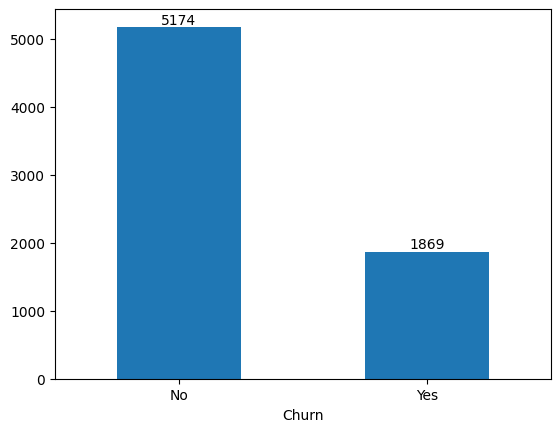

In [39]:
# Usando o normalize = True para pegar o valor da porcentagem
count_churn =  df_churn["Churn"].value_counts().plot.bar(rot=0)
count_churn.bar_label(count_churn.containers[0])

[Text(0, 0, '0.73463'), Text(0, 0, '0.26537')]

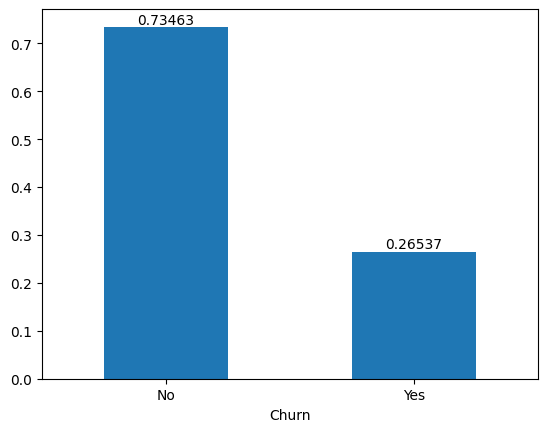

In [40]:
# Usando o normalize = True para pegar o valor da porcentagem
count_churn =  df_churn["Churn"].value_counts(normalize=True).plot.bar(rot=0)
count_churn.bar_label(count_churn.containers[0])

In [41]:
# Usando o Unique para pegar os valores únicos dos contratos
df_churn["Contract"].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

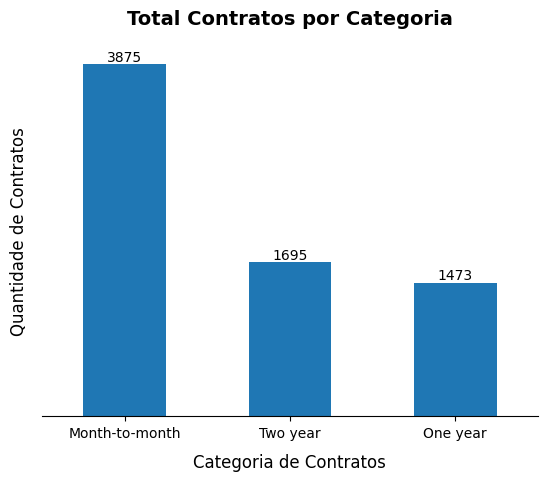

In [42]:
# Total de contratos por categoria
count_contract = df_churn["Contract"].value_counts().sort_values(ascending=False).plot.bar(rot=0)
count_contract.bar_label(count_contract.containers[0])
count_contract.set_yticks([])
count_contract.set_title("Total Contratos por Categoria", fontsize= 14, fontweight= 'bold', loc='center', pad=16)
count_contract.set_xlabel("Categoria de Contratos", labelpad=10, fontsize=12)
count_contract.set_ylabel("Quantidade de Contratos", labelpad=10, fontsize=12)
count_contract.spines[['left', 'right', 'top']].set_visible(False)

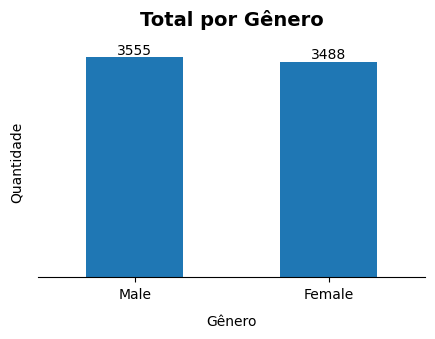

In [54]:
# Analisando o total de clientes por gênero
count_genero = df_churn["Genero"].value_counts().sort_values(ascending=False).plot.bar(rot=0, figsize=(5,3))

count_genero.bar_label(count_genero.containers[0])
count_genero.set_yticks([])
count_genero.set_title("Total por Gênero", fontsize=14, fontweight="bold", loc="center", pad=15)
count_genero.set_xlabel("Gênero", fontsize=10, labelpad=10)
count_genero.set_ylabel("Quantidade", fontsize= 10, labelpad=10)
count_genero.spines[["left", "right", "top"]].set_visible(False)


### Distribuição de variável númerica

In [ ]:
# Analisando a distribuição de clientes por mês atual
df_churn["tenure"].value_counts().reset_index()

,tenure,count
0,1,613
1,72,362
2,2,238
3,3,200
4,4,176
...,...,...
68,28,57
69,39,56
70,44,51
71,36,50


<Axes: ylabel='Frequency'>

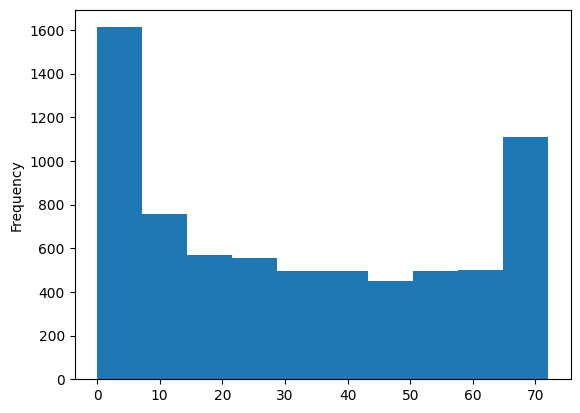

In [ ]:
# Verificando a distribuição com histograma dos clientes por mês atual
df_churn["tenure"].plot.hist()

- É possível observar que a maioria dos clientes/consumidores se encontram nos extremos, ou no inicio entre 0 a 10 meses ou no final entre 65 a 72 meses.

In [ ]:
# Analisando o valor gasto mensalmente pelos clientes
df_churn["MonthlyCharges"].value_counts().reset_index()

,MonthlyCharges,count
0,20.05,61
1,19.85,45
2,19.95,44
3,19.90,44
4,20.00,43
...,...,...
1580,56.85,1
1581,101.70,1
1582,48.40,1
1583,108.35,1


<Axes: ylabel='Frequency'>

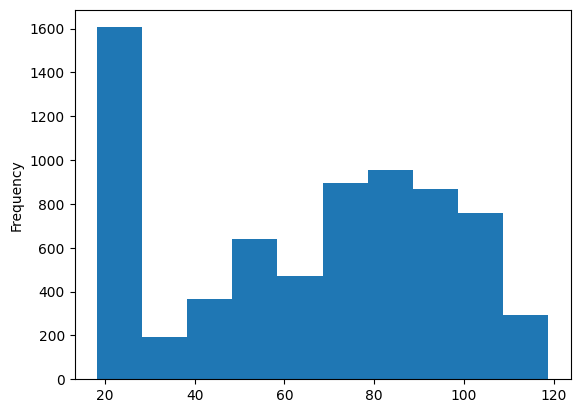

In [51]:
df_churn["MonthlyCharges"].plot.hist()

In [53]:
df_churn["MonthlyCharges"].mean() # A média esta sendo puchada pelos demais valores fora da fixa 20 à 40

np.float64(64.76169246059918)

- É observavél que a maioria dos clientes gastão entre 18,00 a 28,00 por mês.

### Medidas estatísticas

- Medidas de têndencia central
- Medidas de dispersão

In [ ]:
# Usando a média para saber qual é o mês em que a média dos clientes estão
df_churn["tenure"].mean()

np.float64(32.37114865824223)

In [ ]:
# Usando a mediana para saber o mês do meio em que os clientes estão
df_churn["tenure"].median()

np.float64(29.0)

In [58]:
# Usando moda para saber qual é o mês que mais se repete, onde os clientes mais estão
df_churn["tenure"].mode()

0    1
Name: tenure, dtype: int64

In [59]:
''' 
Aplaicando variância para saber o quando os valores se distanciam 
da média do mês em que os clientes se encontram atuamlmente 
'''
df_churn["tenure"].var()

np.float64(603.1681081237368)

In [ ]:
'''
Aplicando o desvio padrão para saber o quão dispersos os clientes 
estão com relação a a média do mês a qual os clientes se encontram atualmente 
'''
df_churn["tenure"].std()

np.float64(24.55948102309446)

In [65]:
'''
Aplicando o coêficiente de variância para saber o quão dispersos os clientes 
estão com relação a a média do mês a qual os clientes se encontram atualmente 
'''
print(round((df_churn["tenure"].std()/df_churn["tenure"].mean())*100,2))

75.87


### Filtros e agrupamentos de valores

In [68]:
''' 
Foi observado, tanto na distribuição usando values_counts quanto ao plotar o gráfico de histograma que a uma grande 
concentração de clientes nos extremos dos dados, principalemnte em 1 mês, onde se encontrão a maior concentração como 
visto ao aplicar a contagem e visualização bem como a moda dos dados. Logo vamos usar o filter para espandir esse intervalor e analisalo melhor.
'''
len(df_churn[df_churn["tenure"]==1]) # Tando os dados filtrados, eu posso pegar-los e usar em uma análise específica de um cenário


613

In [ ]:
# Representando em porcentagem os clientes que se encontram em "tenure == 1" ou seja se encontram no primeiro mês

print(f"{round((len(df_churn[df_churn["tenure"] == 1])/len(df_churn["tenure"]==1))*100,2)} %")

8.7 %


In [97]:
# Verificando se a valores de 1 a 5
lista_tenure = df_churn["tenure"].unique().tolist()
print(sorted(lista_tenure))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72]


In [115]:
# Reprensentado por porcentagem os clientes que estão com o "tenure >= 1 ou tenure<=12", ou seja estão no mês 1 ao 5

print(f"{round((len(df_churn[(df_churn["tenure"]>=1) & (df_churn["tenure"]<=12)])/len(df_churn["tenure"]))*100,2)} %")

# Sempre lembrar de colocar o "()" para multiplas condições 

30.88 %


<Axes: >

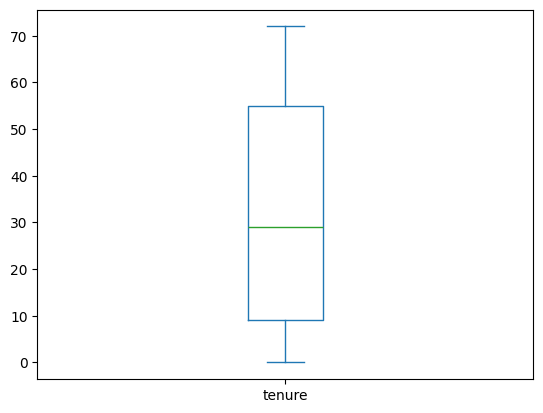

In [111]:
# Fiquei meio em duvida dada a distribuição e resilvi verficar se na há outliers
df_churn["tenure"].plot.box()

<Axes: ylabel='tenure'>

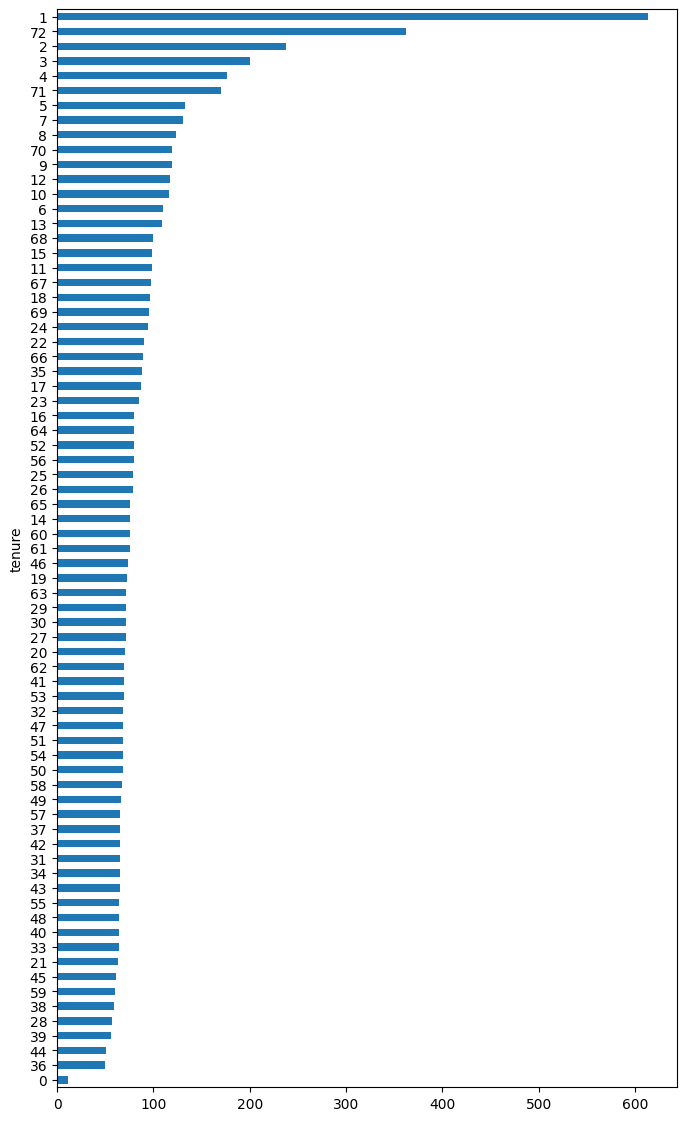

In [141]:
# Quantidade de clinetes por tempo de contrato(gráfico)
df_churn["tenure"].groupby(df_churn["tenure"]).count().sort_values(ascending=True).plot.barh(figsize=(8,14))

### Tabelas de Contigência

In [139]:
# Usando peseudo tabela para analizar o agrupamento entre duas colunas
pd.crosstab(df_churn["Churn"], df_churn["Contract"])

Contract,Month-to-month,One year,Two year
Churn,,,
No,2220,1307,1647
Yes,1655,166,48


- Com essa análise podemos ver que os clientes que passam 1 a 2 anos ultilizando os serviços da empresa tem uma baixa probabilidade de encerrar o contrato.

In [143]:
# Usando o crosstab com parêmetro para conseguir o total e como alterar o valor
pd.crosstab(df_churn["Churn"], df_churn["Contract"], margins=True, margins_name="Total")

Contract,Month-to-month,One year,Two year,Total
Churn,,,,
No,2220,1307,1647,5174
Yes,1655,166,48,1869
Total,3875,1473,1695,7043


In [144]:
# Usando o crosstab com parêmetro para conseguir o total e como alterar o valor, assim como converter em porcentagem
pd.crosstab(df_churn["Churn"], df_churn["Contract"], margins=True, margins_name="Total", normalize=True)


Contract,Month-to-month,One year,Two year,Total
Churn,,,,
No,0.315207,0.185574,0.233849,0.73463
Yes,0.234985,0.023570,0.006815,0.26537
Total,0.550192,0.209144,0.240664,1.00000


In [145]:
# Usando o crosstab com parêmetro para conseguir o total e como alterar o valor, assim como converter em porcentagem retirando o total para colunas
pd.crosstab(df_churn["Churn"], df_churn["Contract"], margins=True, margins_name="Total", normalize='index')


Contract,Month-to-month,One year,Two year
Churn,,,
No,0.429068,0.252609,0.318322
Yes,0.885500,0.088818,0.025682
Total,0.550192,0.209144,0.240664


- Podemos observar que cerca de 55% dos clientes são de mês para mês, 20% estão dentro de um ano e 24% esta dentro de 2 anos
- Podemos observar que 88% dos clientes que cancelaram o serviço, são de mês para mês